## AOC_instability  
Analysed using parallelism plots

In [1]:
# ── Environment setup ─────────────────────────────────────────────────────
# ProxiPal is the project's custom analysis library (ProxiPal.py in repo root).

import sys
from pathlib import Path

module_dir = Path.cwd().parent
sys.path.append(str(module_dir))

from ProxiPal import *
# ProxiPal also imports pandas, numpy, scipy, matplotlib — these are
# available after this line without separate import statements.
# See: https://github.com/jeffsmith8/NfL-iPLA-paper


OS:				 Windows-11-10.0.26200-SP0
Python version:		 3.12.6 | packaged by conda-forge | (main, Sep 22 2024, 14:01:26) [MSC v.1941 64 bit (AMD64)]
Date and Time:		 2026-06-26 17:08:04
cwd:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\user_documents\NfL-PLA Development Paper\NfL-PLA Development Paper Figure Data\GitHub\NfL-iPLA-paper\NfL-iPLA_AOC_instability
base_path:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal
python_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\python
templates_folder:	 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\templates
data_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\data
samples_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\samples
quality_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\quality
user_downloads:		 C:\Users\sm

In [13]:
import pandas as pd

lin_df = pd.read_csv('AOC_instability.csv')

# rebuild lin_list by splitting on source_idx, dropping the tag column,
# and resetting each dataframe's row index
positions = sorted(lin_df['source_idx'].unique())
lin_list = [
    lin_df[lin_df['source_idx'] == pos].drop(columns='source_idx').reset_index(drop=True)
    for pos in positions
]

print(f"Rebuilt lin_list with {len(lin_list)} dataframes.")

Rebuilt lin_list with 18 dataframes.


In [14]:
new_order = [0, 1, 4, 5, 6, 7, 2, 3, 9, 8, 11, 10, 13, 12, 15, 14, 16, 17]  # <-- edit this to whatever order you want

assert sorted(new_order) == list(range(len(lin_list))), \
    f"new_order must be a permutation of 0..{len(lin_list)-1} — check for missing/duplicate indices"

lin_list = [lin_list[i] for i in new_order]

##  Linearity and Parallelism
`sns_linearity_plot()` is a function in ProxiPal that we'll use to compare linearity and parallelism between expected PCR efficiency, observed same-run standards, and the sample.

### How to read this plot

Each panel shows the **dilution linearity** of a single sample (or standard) across a qPCR dilution series, identified in the title by `sample_id` and the experiment folder it was run in.

- **X-axis**: increasing dilution, plotted as `log10_inv_dil` — the log10 of the inverse dilution factor (×100, per the function's internal scaling). Moving left to right represents progressively more diluted material. If `xtick="dilution"` is used (as in the saved figure), the tick labels are converted back to dilution-fold values for readability rather than showing raw log-inverse numbers.

- **Y-axis**: mean Cq (`ct_mean_y`) at each dilution point — i.e. the cycle threshold, which is the PCR cycle number at which fluorescence crosses the detection baseline. Because `inv_y=True` is set, the axis is inverted, so visually "higher" on the plot corresponds to a **lower Cq** — meaning brighter/earlier-detected signal sits toward the top, consistent with the y-axis label "Cq" but with the inversion making "up" intuitively mean "more signal." With `inv_x=True` also set, the x-axis is similarly flipped.

- **Black line with X markers**: the actual observed data — `ct_mean_y` plotted against `log10_inv_dil` for that sample. This is the empirical result being evaluated.

- **Red line**: not data — a straight line constructed from the externally-supplied gradient (`m`, from the `gradient_column` argument) anchored at one end of the dilution range (`origin='[x2,y2]'` anchors it at the most-diluted point, using the sample's own fitted gradient). It represents what the ideal linear fit would look like if the sample's Cq response followed exactly the gradient computed for it — a visual reference for "this is the line my own fitted slope predicts," so you can see how closely the actual black-line data tracks its own regression.

- **Orange/yellow shaded band**: an acceptable-performance envelope, not derived from this sample's own data at all — built from two fixed reference gradients corresponding to **95% and 105% PCR amplification efficiency** (`m1_model = -3.207`, `m2_model = -3.448`, the standard Cq-vs-log-dilution slopes for those efficiency bounds under ideal doubling kinetics). Anchored at the same point as the red line, this band shows the range of slopes that would be considered acceptable PCR efficiency for a dilution series of this size. If the black data line stays inside the shaded band, the assay's amplification efficiency for that sample falls within the conventionally accepted 95–105% range; if it strays outside, efficiency is off-spec.

- **Annotated text** (bottom-left, or repositioned depending on `inv_x`/`inv_y`): `specimen_type` and `collection_type` — i.e., what kind of biological material this is and how it was collected, given as plain-text context rather than encoded in the title.

**The practical read**: a "good" panel is one where the black data line runs close to parallel with the red reference line and stays within the orange band across the full dilution range — that tells you the sample diluted predictably and the assay behaved with near-ideal amplification efficiency for that specific sample. Deviation from linearity (data line curving away from the red line) suggests matrix effects, saturation at low dilution, or detection-limit dropout at high dilution; a data line that's roughly parallel to red but sitting **outside** the orange band indicates consistent linearity but with off-target amplification efficiency, a distinct failure mode from nonlinearity itself.

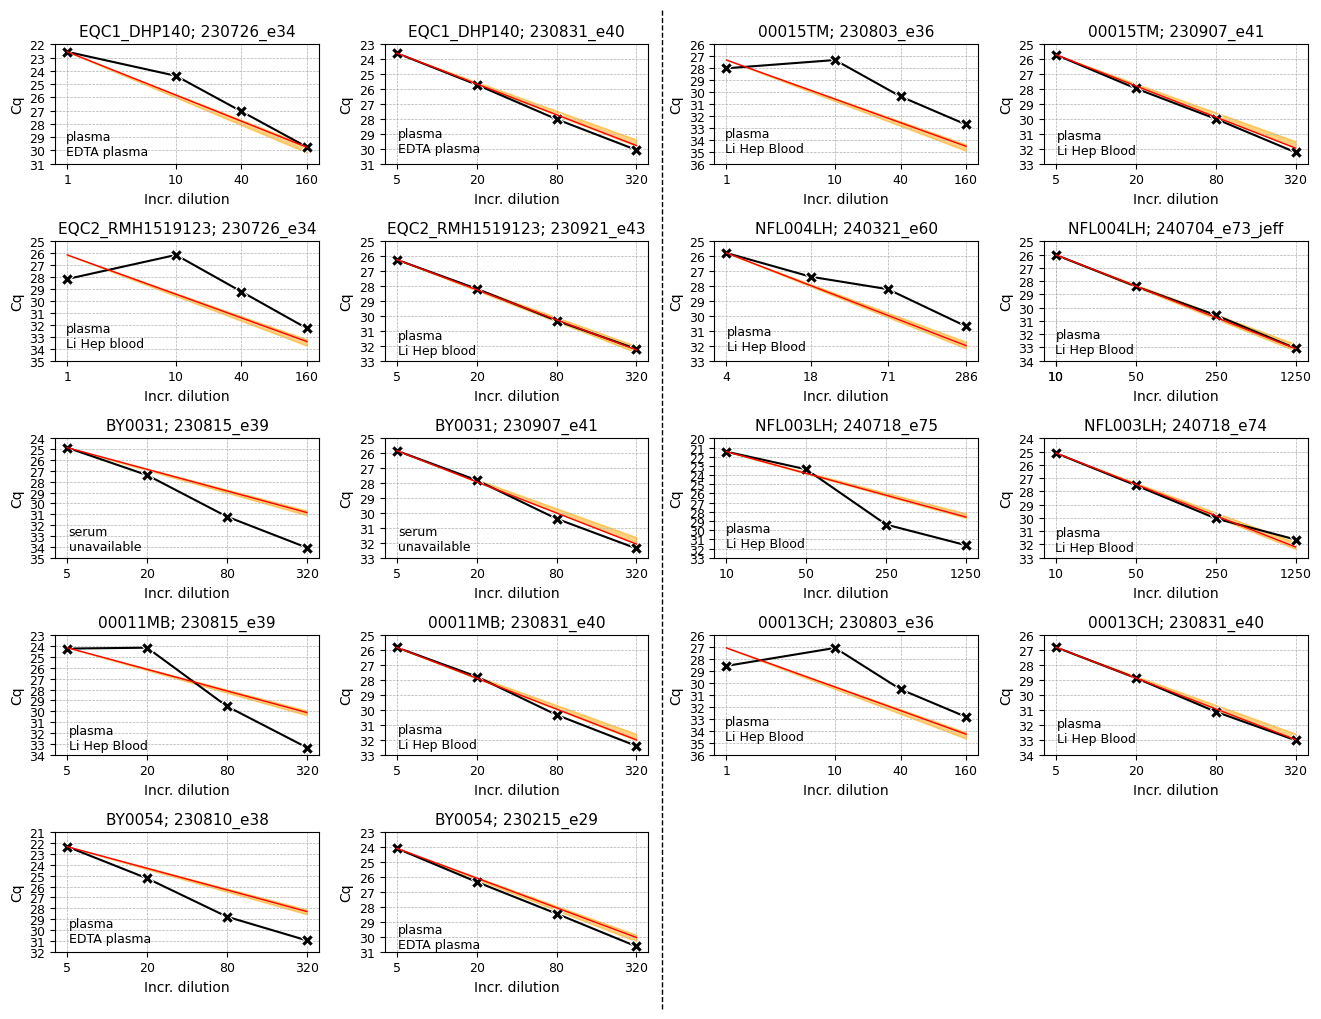

In [17]:
import math
import matplotlib.pyplot as plt

n = len(lin_list)
ncols = 4
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(10/3 * ncols, 6/3 * nrows))
axes = axes.flatten()  # so it's a flat 1D array regardless of nrows/ncols

for i, df in enumerate(lin_list):
    sns_linearity_plot(df, inv_y=True, inv_x=True, origin='[x2,y2]',
                        xlab='Incr. dilution', ylab='Cq',
                        xtick="dilution", ax=axes[i])

# hide any unused subplot axes (now relevant: 18 panels in a 5x4=20 grid leaves 2 empty)
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()

# --- vertical dashed divider between columns 2 and 3, spanning the full figure height ---
fig.add_artist(plt.Line2D([0.5, 0.5], [0, 1], transform=fig.transFigure,
                           color='black', linestyle='--', linewidth=1))

fig.savefig('linearity_panel.svg', format='svg', bbox_inches='tight')
plt.show()